# Explorations and Analysis of the ENTSO-E data

In [ ]:
# Fix the path 
import sys
import os
from dotenv import load_dotenv

# create .env file in the same directory as the script
# export ENTSOE_API_KEY="YOUR_API_KEY"
# export QUANT_DB_HOST="localhost"
# export QUANT_DB_PORT="5432"
# export QUANT_DB_NAME="options_db"
# export QUANT_DB_USER="quant_user"
# export QUANT_DB_PASSWORD="strong_password"

load_dotenv()
sys.path.append(os.path.abspath(".."))  
os.getenv("ENTSOE_API_KEY")
os.getenv("QUANT_DB_HOST")
os.getenv("QUANT_DB_PORT")
os.getenv("QUANT_DB_NAME")
os.getenv("QUANT_DB_USER")
os.getenv("QUANT_DB_PASSWORD")


'strong_password'

In [40]:
# import necessary libraries
import importlib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Ensure notebook picks up local code edits without kernel restarts
%load_ext autoreload
%autoreload 2

# custom imports
import electricity_price_predictor.entsoe_api as api
import electricity_price_predictor.pipeline as pipeline

importlib.reload(api)
importlib.reload(pipeline)

from electricity_price_predictor.db import get_engine
from electricity_price_predictor.pipeline import run_feature_pipeline


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
def access_data(
    start: pd.Timestamp,
    end: pd.Timestamp,
    country_code: str,
    history_hours: int = 48,
) -> pd.DataFrame:
    """
    Fetch features for [start, end) while pulling extra lookback history.

    We need lookback because feature generation creates lagged columns (t-1..t-24)
    and drops rows with NaNs.
    """
    api_key = os.getenv("ENTSOE_API_KEY")
    if not api_key:
        raise RuntimeError("ENTSOE_API_KEY environment variable is required.")

    start_ts = pd.Timestamp(start)
    end_ts = pd.Timestamp(end)
    if start_ts.tz is None:
        start_ts = start_ts.tz_localize("UTC")
    else:
        start_ts = start_ts.tz_convert("UTC")

    if end_ts.tz is None:
        end_ts = end_ts.tz_localize("UTC")
    else:
        end_ts = end_ts.tz_convert("UTC")

    engine = get_engine()
    pipeline_start = start_ts - pd.Timedelta(hours=history_hours)

    features = run_feature_pipeline(
        engine=engine,
        entsoe_api_key=api_key,
        country_code=country_code,
        start=pipeline_start,
        end=end_ts,
        cache_ttl_hours=24,
    )

    # Return only the user-requested interval.
    return features[(features.index >= start_ts) & (features.index < end_ts)]



In [42]:
# Pull the latest 48h window ending at the most recent complete hour.
end = pd.Timestamp.now(tz="UTC").floor("h")
start = end - pd.Timedelta(hours=48)

df_CH = access_data(start, end, "CH", history_hours=72)


# pull German data for comparison 
df_DE = access_data(start, end, "DE_LU", history_hours=72)
# pull French data for comparison 
df_FR = access_data(start, end, "FR", history_hours=72)
# pull Italian data for comparison 
df_IT = access_data(start, end, "IT", history_hours=72)
# pull Austrian data for comparison 
df_AT = access_data(start, end, "AT", history_hours=72)
# pull Spanish data for comparison 
df_ES = access_data(start, end, "ES", history_hours=72)




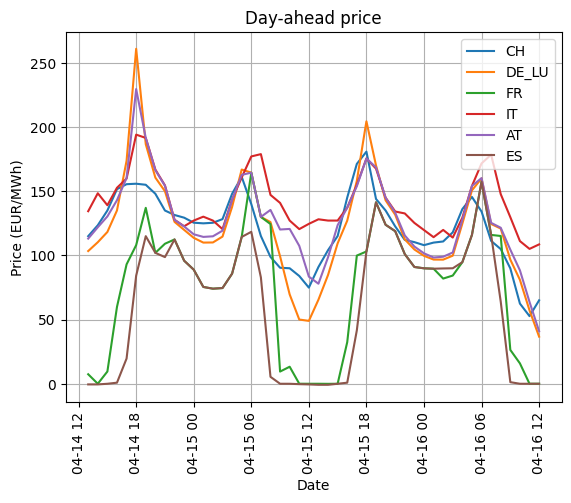

In [43]:
plt.plot(df_CH.index, df_CH["day_ahead_price"], label="CH")
plt.plot(df_DE.index, df_DE["day_ahead_price"], label="DE_LU")
plt.plot(df_FR.index, df_FR["day_ahead_price"], label="FR")
plt.plot(df_IT.index, df_IT["day_ahead_price"], label="IT")
plt.plot(df_AT.index, df_AT["day_ahead_price"], label="AT")
plt.plot(df_ES.index, df_ES["day_ahead_price"], label="ES")

plt.xticks(rotation=90)
plt.grid()
plt.title("Day-ahead price")
plt.xlabel("Date")
plt.ylabel("Price (EUR/MWh)")
plt.legend()

plt.show()




## Feature engineering 
In the next section we are going to explore which features are justifiable with the given data. 

In [44]:
df_CH.columns

Index(['day_ahead_price', 'load_forecast', 'wind_forecast', 'solar_forecast',
       'residual_load', 'lagged_price_1', 'lagged_residual_load_1',
       'lagged_price_2', 'lagged_residual_load_2', 'lagged_price_3',
       'lagged_residual_load_3', 'lagged_price_4', 'lagged_residual_load_4',
       'lagged_price_5', 'lagged_residual_load_5', 'lagged_price_6',
       'lagged_residual_load_6', 'lagged_price_7', 'lagged_residual_load_7',
       'lagged_price_8', 'lagged_residual_load_8', 'lagged_price_9',
       'lagged_residual_load_9', 'lagged_price_10', 'lagged_residual_load_10',
       'lagged_price_11', 'lagged_residual_load_11', 'lagged_price_12',
       'lagged_residual_load_12', 'lagged_price_13', 'lagged_residual_load_13',
       'lagged_price_14', 'lagged_residual_load_14', 'lagged_price_15',
       'lagged_residual_load_15', 'lagged_price_16', 'lagged_residual_load_16',
       'lagged_price_17', 'lagged_residual_load_17', 'lagged_price_18',
       'lagged_residual_load_18', 'lag

<Axes: >

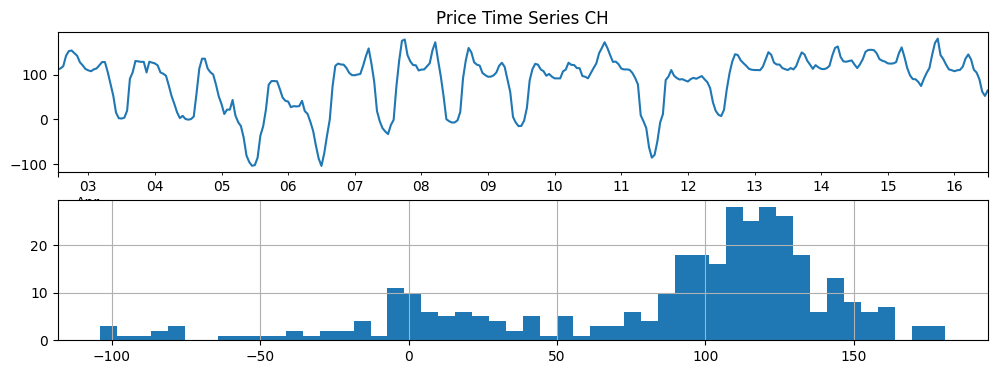

In [45]:
fig, axes = plt.subplots(2,1,figsize=(12,4))
end = pd.Timestamp.now(tz="UTC").floor("h")
start = end - pd.Timedelta(hours=14*24)
df = access_data(start, end, "CH", history_hours=72)
df["day_ahead_price"].plot(ax = axes[0], title = "Price Time Series CH")
df["day_ahead_price"].hist(bins=50, ax = axes[1])

Observations: 

* Intraday seasonality 
* $\mu \approx 125$
* Noise 

An approach could be to model it as 

Price(t) = µ + seasonal(t) + noise

In [46]:
# Fit an AR(1) process: X_t = c + phi * X_{t-1} + eps_t
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Use existing `ts` if available; otherwise fall back to the day-ahead price series
if "ts" not in locals():
    ts = df["day_ahead_price"]

ts_ar1 = pd.Series(ts)
# Convert to numeric (coerce invalid values to NaN)
ts_ar1 = pd.to_numeric(ts_ar1, errors="coerce").dropna()
if len(ts_ar1) < 3:
    raise ValueError("Not enough observations to fit AR(1).")

x_t = ts_ar1.iloc[1:]
x_lag = ts_ar1.shift(1).iloc[1:]

X = sm.add_constant(x_lag)
ar1_model = sm.OLS(x_t, X).fit()

mu = ar1_model.params["const"]
phi = ar1_model.params[x_lag.name] if x_lag.name in ar1_model.params.index else ar1_model.params.iloc[1]
sigma = float(np.sqrt(ar1_model.mse_resid))

print(f"AR(1) fit complete on {len(x_t)} observations")
print(f"mu (intercept): {mu:.6f}")
print(f"phi (lag-1 coefficient): {phi:.6f}")
print(f"sigma (residual std): {sigma:.6f}")

ar1_model.summary()

AR(1) fit complete on 335 observations
mu (intercept): 5.022831
phi (lag-1 coefficient): 0.941551
sigma (residual std): 20.320028


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:        day_ahead_price   R-squared:                       0.887
Model:                            OLS   Adj. R-squared:                  0.886
Method:                 Least Squares   F-statistic:                     2606.
Date:                Thu, 16 Apr 2026   Prob (F-statistic):          1.54e-159
Time:                        15:21:55   Log-Likelihood:                -1483.2
No. Observations:                 335   AIC:                             2970.
Df Residuals:                     333   BIC:                             2978.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               5.0228      1.940      2.589      0.010       1.207       8.839
day_ahead_price     0.9416      0.018     51.053      0.000       0.905       0.978
==============================================================================
Omnibus:                       33.460   Durbin-Watson:                   0.767
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               88.092
Skew:                           0.454   Prob(JB):                     7.43e-20
Kurtosis:                       5.343   Cond. No.                         184.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

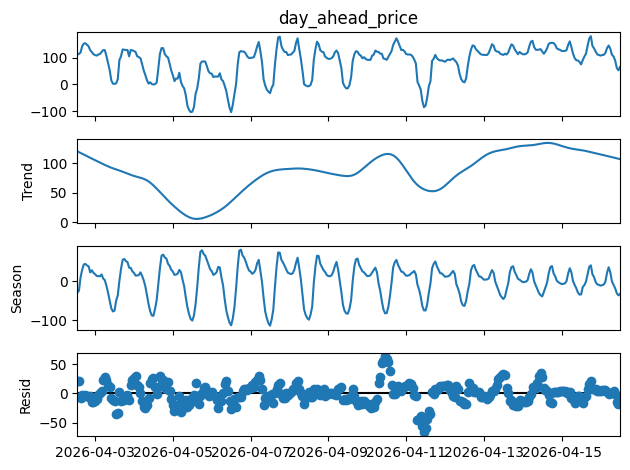

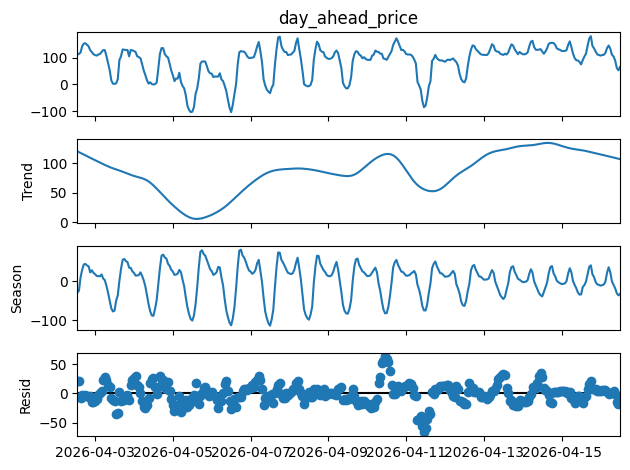

In [47]:
# Let's explore this further with an STL decomposition 
from statsmodels.tsa.seasonal import STL 

ts = df["day_ahead_price"]

stl = STL(ts, period=24)
res = stl.fit()

res.plot()




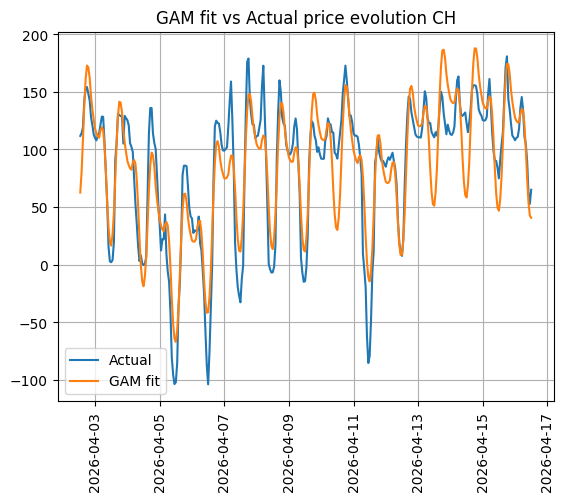

In [48]:
# Model with gam 
df["hour"] = df.index.hour 
df["t"] = range(len(df))

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

from pygam import LinearGAM, s 

X = df[["t", "hour_sin", "hour_cos"]].values
y = df["day_ahead_price"].values 

gam = LinearGAM(s(0) + s(1) + s(2)).fit(X, y)

y_pred = gam.predict(X)

plt.plot(df.index, y, label="Actual")
plt.plot(df.index, y_pred, label="GAM fit")
plt.xticks(rotation = 90)
plt.title("GAM fit vs Actual price evolution CH")
plt.grid()
plt.legend()
plt.show()

To check if this type of model explains the prices well, we check the residuals. 

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     27.3735
Link Function:                     IdentityLink Log Likelihood:                                 -1585.5042
Number of Samples:                          336 AIC:                                             3227.7554
                                                AICc:                                            3233.1915
                                                GCV:                                                932.94
                                                Scale:                                             28.2349
                                                Pseudo R-Squared:                                   0.7975
Feature Function                  Lam

/var/folders/0r/jb7z1qk9795_hzp0h_jhb31w0000gn/T/ipykernel_48452/2225750900.py:1: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


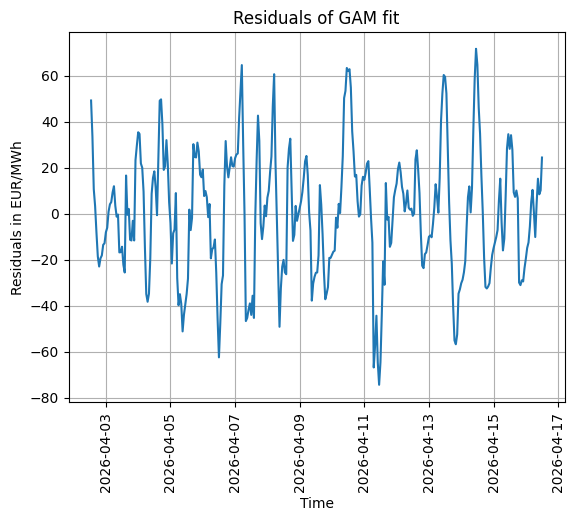

In [49]:
gam.summary()
resid = gam.deviance_residuals(X,y)

plt.plot(df.index, gam.deviance_residuals(X,y))
plt.title("Residuals of GAM fit")
plt.xlabel("Time")
plt.ylabel("Residuals in EUR/MWh")
plt.xticks(rotation = 90)
plt.grid()
plt.show()





We observe that that the residuals seem to be approximately mean zero and patternless by eye, so the GAM appears to have removed most of the trend and seasonality. But we still need diagnostics for claiming stationarity. 

Mean residual 3.643772289187891e-09
Std residual 27.06032850658655


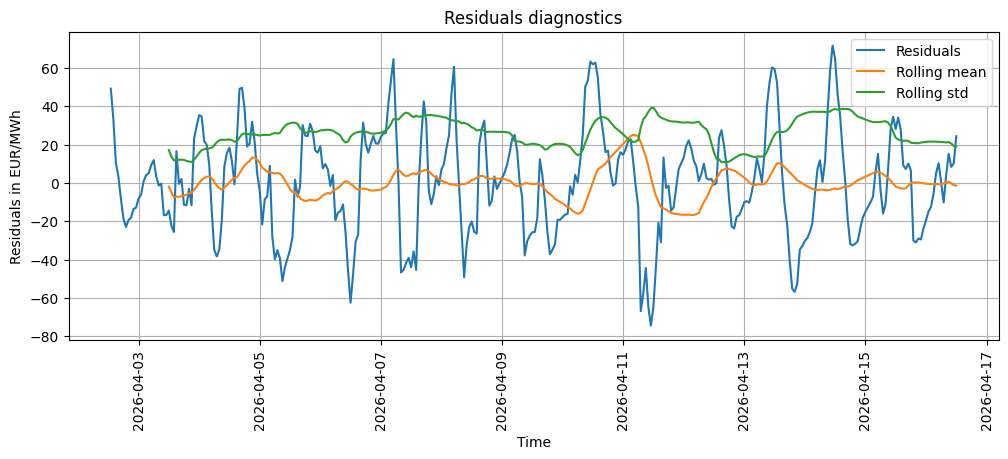

In [50]:
print("Mean residual", resid.mean())
print("Std residual", resid.std())

resid_s = pd.Series(resid, index=df.index)

plt.figure(figsize=(12,4))
plt.plot(resid_s, label="Residuals")
plt.plot(resid_s.rolling(24).mean(), label="Rolling mean")
plt.plot(resid_s.rolling(24).std(), label="Rolling std")
plt.title("Residuals diagnostics")
plt.xlabel("Time")
plt.ylabel("Residuals in EUR/MWh")
plt.xticks(rotation = 90)
plt.grid()
plt.legend()
plt.show()








Indeed the mean is close to zero and the standard deviation is contained by 40 EUR/MWh. 

Next we have to investigate the autocorrelation structure. 

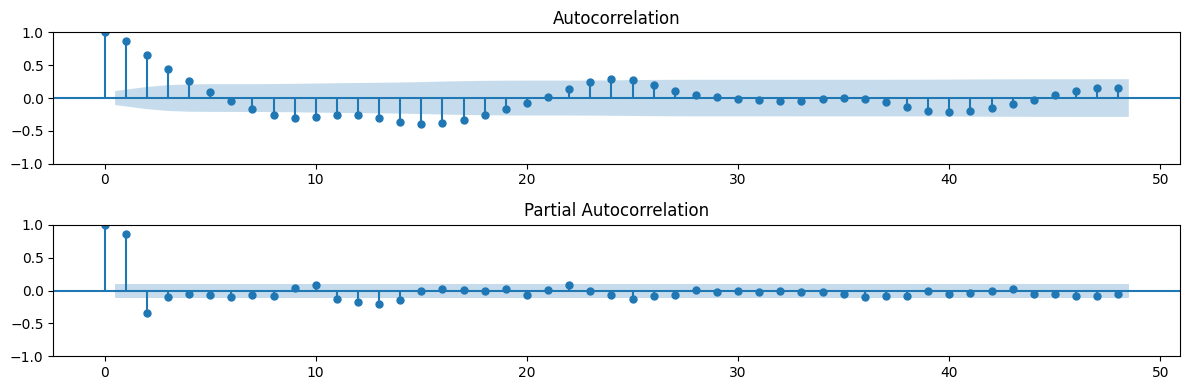

In [51]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf 

fig, ax = plt.subplots(2,1, figsize = (12,4))
plot_acf(resid, lags = 48, ax = ax[0])
plot_pacf(resid, lags = 48, ax = ax[1], method = "ywm")
plt.tight_layout()
plt.show()





One can see large spikes in the autocorrelation for lag 1 - 5 (outside of the confidence band). This means that actually the residuals are not uncorrelated. In fact, they could be modeled with an AR(1) process. 

const   -0.083785
y.L1     0.865762
dtype: float64
AR(1) fit complete on 336 observations
mu (intercept): -0.083785
phi (lag-1 coefficient): 0.865762
sigma (residual std): 13.343410


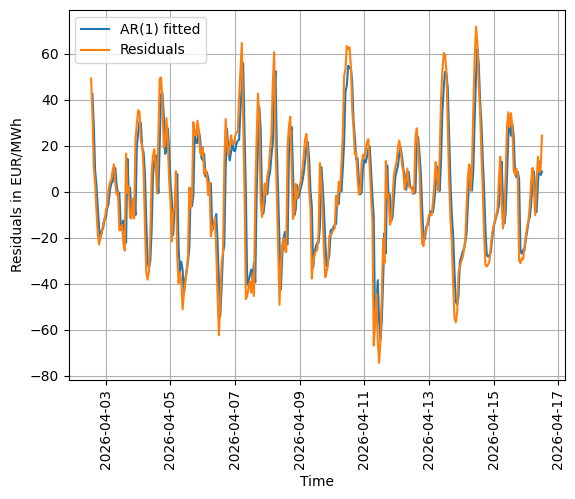

RMSE: 13.3434
MAE:  9.6599


<class 'statsmodels.iolib.summary.Summary'>
"""
                            AutoReg Model Results                             
==============================================================================
Dep. Variable:                      y   No. Observations:                  336
Model:                     AutoReg(1)   Log Likelihood               -1343.337
Method:               Conditional MLE   S.D. of innovations             13.343
Date:                Thu, 16 Apr 2026   AIC                           2692.674
Time:                        15:21:56   BIC                           2704.116
Sample:                    04-02-2026   HQIC                          2697.236
                         - 04-16-2026                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0838      0.729     -0.115      0.909      -1.513       1.345
y.L1           0.8658      0.027     32.145      0.000       0.813       0.919
                                    Roots                                    
=============================================================================
                  Real          Imaginary           Modulus         Frequency
-----------------------------------------------------------------------------
AR.1            1.1551           +0.0000j            1.1551            0.0000
-----------------------------------------------------------------------------
"""

In [52]:
# Robust AR(1) fit + visual comparison
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg


# Fit AR(1): X_t = c + phi * X_{t-1} + eps_t
ar1 = AutoReg(resid_s, lags=1, old_names=False).fit()
params = ar1.params
print(params)

mu = float(params["const"])
phi = float(params["y.L1"])
sigma = float(np.sqrt(ar1.sigma2))


print(f"AR(1) fit complete on {len(resid_s.values)} observations")
print(f"mu (intercept): {mu:.6f}")
print(f"phi (lag-1 coefficient): {phi:.6f}")
print(f"sigma (residual std): {sigma:.6f}")

# In-sample one-step-ahead fitted values
fitted = ar1.fittedvalues
aligned_actual = resid_s.loc[fitted.index]


plt.plot(fitted.index, fitted, label = "AR(1) fitted")
plt.plot(resid_s.index, resid_s, label = "Residuals")
plt.xlabel("Time")
plt.ylabel("Residuals in EUR/MWh")
plt.xticks(rotation = 90)
plt.grid()
plt.legend()
plt.show()




# Quick fit metrics
rmse = float(np.sqrt(np.mean((aligned_actual - fitted) ** 2)))
mae = float(np.mean(np.abs(aligned_actual - fitted)))
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

ar1.summary()

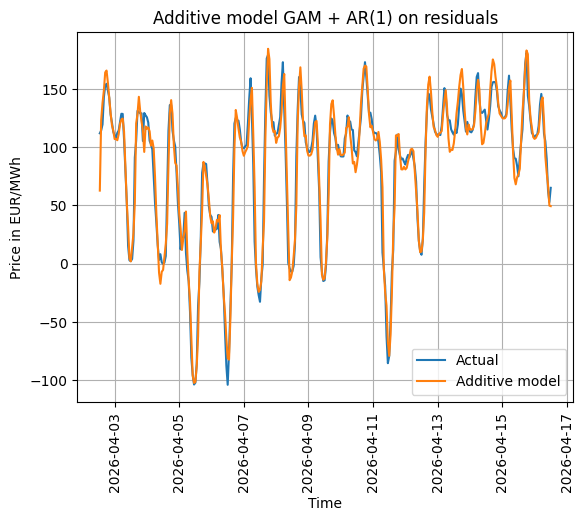

In [53]:
# Now we check if upon additive combination of the two models, we get a good fit. 
additive_model = y_pred + np.insert(ar1.fittedvalues, 0, 0)

plt.plot(df.index, df["day_ahead_price"], label = "Actual")
plt.plot(df.index, additive_model, label = "Additive model")
plt.xlabel("Time")
plt.ylabel("Price in EUR/MWh")
plt.xticks(rotation = 90)
plt.grid()
plt.title("Additive model GAM + AR(1) on residuals")
plt.legend()
plt.show()

# Now we check if upon additive combination of the two models, we get a good fit. 
additive_model = y_pred + np.insert(ar1.fittedvalues, 0, 0)

plt.plot(df.index, df["day_ahead_price"], label = "Actual")
plt.plot(df.index, additive_model, label = "Additive model")
plt.xlabel("Time")
plt.ylabel("Price in EUR/MWh")
plt.xticks(rotation = 90)
plt.grid()
plt.title("Additive model GAM + AR(1) on residuals")
plt.legend()
plt.show()


Seemingly this additive model is explaining the time series better than only the GAM. 
# LightGBM Machine Learning model

In [ ]:

# Split the data into target_col and feature_cols
import numpy as np
import pandas as pd
# Predictions
from sklearn.metrics import mean_absolute_error, mean_squared_error
def lgbm_train_benchmark(df): 
    target_col = "day_ahead_price"
    feature_cols = [col for col in df.columns if col != target_col]

    # LightGBM requires numeric dtypes. Coerce object columns and drop rows that become NaN.
    df_model = df[feature_cols + [target_col]].copy()
    df_model[feature_cols + [target_col]] = df_model[feature_cols + [target_col]].apply(
        pd.to_numeric,
        errors="coerce"
    )
    df_model = df_model.dropna().copy()

    if df_model.empty:
        raise ValueError("No rows left after numeric coercion and NaN removal.")

    # Split the data into training, validation and test set
    n = len(df_model)
    train_end = int(n * 0.7)
    valid_end = int(n * 0.85)

    train = df_model.iloc[:train_end]
    valid = df_model.iloc[train_end:valid_end]
    test = df_model.iloc[valid_end:]

    # Define the feature matrices and target vectors
    X_train = train[feature_cols]
    y_train = train[target_col]
    X_valid = valid[feature_cols]
    y_valid = valid[target_col]
    X_test = test[feature_cols]
    y_test = test[target_col]

    # Sanity check: all feature columns must be numeric for LightGBM
    non_numeric_cols = X_train.select_dtypes(exclude=[np.number, "bool"]).columns.tolist()
    if non_numeric_cols:
        raise ValueError(f"Non-numeric columns found in training data: {non_numeric_cols}")

    # Define the LightGBM model
    import lightgbm as lgb
    model = lgb.LGBMRegressor(
        objective="regression",
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=6,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=0.1,
        random_state=42,
        # Keep LightGBM logs quiet inside notebooks.
        verbosity=-1
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric="l1", 
        callbacks=[lgb.early_stopping(100)]
    )
    def rmse(y_true, y_pred):
        return np.sqrt(mean_squared_error(y_true, y_pred))

    valid_pred = model.predict(X_valid)
    test_pred = model.predict(X_test)

    print("Validation MAE:", mean_absolute_error(y_valid, valid_pred))
    print("Validation RMSE:", rmse(y_valid, valid_pred))

    print("Test MAE:", mean_absolute_error(y_test, test_pred))
    print("Test RMSE:", rmse(y_test, test_pred))

    # Benchmark against naive model
    naive_pred = test["lagged_price_24"]

    print("Naive MAE:", mean_absolute_error(y_test, naive_pred))
    print("Naive RMSE:", rmse(y_test, naive_pred))
    return y_valid, y_test, valid_pred, test_pred, y_train, df_model, train_end, valid_end

lgbm_train_benchmark(df)
days = 50
end = pd.Timestamp.now(tz="UTC").floor("h")
start = pd.Timestamp.now(tz="UTC").floor("h") - pd.Timedelta(hours=24 * days)
df = access_data(start, end, "CH", history_hours=72)
y_valid, y_test, valid_pred, test_pred, y_train, df_model, train_end, valid_end = lgbm_train_benchmark(df)






Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[315]	valid_0's l1: 10.9597	valid_0's l2: 196.411
Validation MAE: 10.959664311138797
Validation RMSE: 14.014664510066716
Test MAE: 12.152364989141372
Test RMSE: 16.679012015257562
Naive MAE: 19.994468085106384
Naive RMSE: 28.702402672057552
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[976]	valid_0's l1: 21.7012	valid_0's l2: 1122.43
Validation MAE: 21.701185967270423
Validation RMSE: 33.502714583720824
Test MAE: 14.949805263426754
Test RMSE: 22.72371411662752
Naive MAE: 35.1857627118644
Naive RMSE: 50.7071144787106


In [64]:
def compute_additive_model_gam_ar1(
    df,
    target_col="day_ahead_price",
    gam_feature_cols=("hour_sin", "hour_cos"),
    ar_lags=1,
    gam_terms=None,
    return_components=False,
    train_frac=0.7,
    valid_frac=0.85,
    train_end=None,
    valid_end=None,
    forecast_mode="rolling_one_step",
):
    """Leakage-free GAM + AR(1) additive model on GAM residuals.

    Main fixes vs the previous implementation:
    1) Default GAM uses only stable seasonal features (no spline on absolute time `t`).
    2) AR is fit on raw residuals (y - y_hat_gam) from the training slice.
    3) Future residuals are generated via AR recursion without refitting.
       - forecast_mode="recursive": multi-step forecast (no refreshing with realized residuals)
       - forecast_mode="rolling_one_step": one-step rolling forecast (refresh AR history using realized residuals)

    Returns a pd.Series aligned to df.index.
    """

    import numpy as np
    import pandas as pd

    from pygam import LinearGAM, s
    from statsmodels.tsa.ar_model import AutoReg

    df_work = df.copy()
    df_work = df_work.sort_index()

    # --- Ensure required GAM feature columns exist (computed from index only)
    n = len(df_work)
    if n < max(10, ar_lags + 5):
        raise ValueError(f"Not enough rows for ar_lags={ar_lags}: n={n}")

    # Time-derived seasonal features
    if "hour_sin" in gam_feature_cols and "hour_sin" not in df_work.columns:
        hour = df_work.index.hour
        df_work["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    if "hour_cos" in gam_feature_cols and "hour_cos" not in df_work.columns:
        hour = df_work.index.hour
        df_work["hour_cos"] = np.cos(2 * np.pi * hour / 24)

    # Optional linear time index (only if user explicitly asks for it)
    if "t" in gam_feature_cols and "t" not in df_work.columns:
        df_work["t"] = np.arange(n, dtype=float)

    required_cols = list(gam_feature_cols) + [target_col]
    missing = [c for c in required_cols if c not in df_work.columns]
    if missing:
        raise KeyError(f"Missing required columns in df: {missing}")

    # --- Split indices (must match LightGBM split fractions used elsewhere)
    if train_end is None:
        train_end = int(n * train_frac)
    if valid_end is None:
        valid_end = int(n * valid_frac)

    if not (0 < train_end < valid_end < n):
        raise ValueError(
            f"Invalid split: train_end={train_end}, valid_end={valid_end}, n={n}. "
            "Need 0 < train_end < valid_end < n."
        )

    # --- Build GAM design matrix and target
    X_all = df_work[list(gam_feature_cols)].values
    y_all = df_work[target_col].values

    X_train = X_all[:train_end]
    y_train = y_all[:train_end]

    # --- Fit GAM only on the training slice
    if gam_terms is None:
        # Build one smoothing term per input feature dimension.
        # (Cannot do sum() here because pyGAM terms do not add with an initial 0.)
        gam_terms = s(0)
        for i in range(1, X_all.shape[1]):
            gam_terms = gam_terms + s(i)

    gam = LinearGAM(gam_terms).fit(X_train, y_train)

    # GAM predictions for all timestamps are allowed (no y-leakage), but
    # stable features are required to avoid spline extrapolation blow-ups.
    y_pred_all = gam.predict(X_all)

    # --- Raw residuals from GAM (fit AR only on training residuals)
    y_pred_train = gam.predict(X_train)
    resid_train = y_train - y_pred_train
    resid_train_s = pd.Series(resid_train, index=df_work.index[:train_end])

    # --- Fit AR(p) on the training residuals only
    ar_model = AutoReg(resid_train_s, lags=ar_lags, old_names=False).fit()

    # Extract intercept and lag coefficients in parameter order.
    params_arr = np.asarray(ar_model.params, dtype=float)
    if len(params_arr) < 1 + ar_lags:
        raise ValueError(f"Unexpected AR params length: {len(params_arr)}")

    intercept = float(params_arr[0])
    phi = params_arr[1 : 1 + ar_lags]  # shape (ar_lags,)

    # --- Residual prediction stream
    resid_true_all = y_all - y_pred_all

    # In-sample fitted residuals from AR for the training tail.
    # AutoReg.fittedvalues are one-step-ahead residual predictions for indices
    # [ar_lags, ..., train_end-1] (length = train_end - ar_lags).
    fitted_resid_train = np.asarray(ar_model.fittedvalues, dtype=float)

    resid_pred = np.zeros(n, dtype=float)
    if train_end - ar_lags > 0:
        resid_pred[ar_lags:train_end] = fitted_resid_train

    # History buffer for recursion
    resid_history = np.zeros(n, dtype=float)
    resid_history[:train_end] = resid_train

    if forecast_mode not in {"recursive", "rolling_one_step"}:
        raise ValueError("forecast_mode must be 'recursive' or 'rolling_one_step'")

    for t_idx in range(train_end, n):
        past = resid_history[t_idx - ar_lags : t_idx][::-1]  # resid_{t-1},...,resid_{t-p}
        resid_pred[t_idx] = intercept + float(np.dot(phi, past))

        # Update AR history for next step.
        if forecast_mode == "recursive":
            resid_history[t_idx] = resid_pred[t_idx]
        else:
            # rolling_one_step: refresh with realized residual at t_idx
            resid_history[t_idx] = resid_true_all[t_idx]

    additive_model = y_pred_all + resid_pred
    out = pd.Series(additive_model, index=df_work.index, name="gam_ar1_additive_model")

    if return_components:
        return out, {
            "gam": gam,
            "ar_model": ar_model,
            "y_pred_all": y_pred_all,
            "resid_true_all": resid_true_all,
            "resid_pred": resid_pred,
        }

    return out


In [65]:
# Benchmark: statistical GAM + AR(1) model vs LightGBM on the same split

from sklearn.metrics import mean_absolute_error, mean_squared_error

# We previously defined:
# - y_pred: GAM in-sample predictions for df["day_ahead_price"]
# - ar1: AR(1) model fitted on the residuals resid_s
# - additive_model: full-series additive prediction y_pred + AR(1) fitted residuals

# Align additive_model with the LightGBM feature-matrix index, just to be explicit
#stat_full = pd.Series(additive_model, index=df_model.index)
stat_full = compute_additive_model_gam_ar1(df_model)

# Helper to compute metrics for any prediction series aligned with df.index

def _split_and_score_stat_model(stat_series, label):
    """Compute MAE/RMSE on train/valid/test using the same split as LightGBM."""
    # Use the same df_model index and masking as for LightGBM
    # (only rows that survived numeric coercion / dropna)
    idx_model = df_model.index
    stat_on_model = stat_series.reindex(idx_model)

    # Use the existing train/valid/test index locations
    stat_train = stat_on_model.iloc[:train_end]
    stat_valid = stat_on_model.iloc[train_end:valid_end]
    stat_test = stat_on_model.iloc[valid_end:]

    # Targets already defined: y_train, y_valid, y_test
    def rmse_fn(y_true, y_hat):
        return np.sqrt(mean_squared_error(y_true, y_hat))

    print()
    print(f"{label} – Train:")
    print("  MAE:", mean_absolute_error(y_train, stat_train))
    print("  RMSE:", rmse_fn(y_train, stat_train))

    print(f"{label} – Validation:")
    print("  MAE:", mean_absolute_error(y_valid, stat_valid))
    print("  RMSE:", rmse_fn(y_valid, stat_valid))

    print(f"{label} – Test:")
    print("  MAE:", mean_absolute_error(y_test, stat_test))
    print("  RMSE:", rmse_fn(y_test, stat_test))


_split_and_score_stat_model(stat_full, label="GAM + AR(1) additive model")
def rmse(y_true, y_pred):
        return np.sqrt(mean_squared_error(y_true, y_pred))
# For convenience, also print the LightGBM metrics again here
print()
print("LightGBM – Validation:")
print("  MAE:", mean_absolute_error(y_valid, valid_pred))
print("  RMSE:", rmse(y_valid, valid_pred))

print("LightGBM – Test:")
print("  MAE:", mean_absolute_error(y_test, test_pred))
print("  RMSE:", rmse(y_test, test_pred))



GAM + AR(1) additive model – Train:
  MAE: 7.503859280659794
  RMSE: 12.041679899201137
GAM + AR(1) additive model – Validation:
  MAE: 12.92925708919014
  RMSE: 17.8525039460463
GAM + AR(1) additive model – Test:
  MAE: 10.214595090155559
  RMSE: 15.225938101923314

LightGBM – Validation:
  MAE: 21.701185967270423
  RMSE: 33.502714583720824
LightGBM – Test:
  MAE: 14.949805263426754
  RMSE: 22.72371411662752


/Users/daviddoebel/CLionProjects/QuantProjects/option_pricing/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


# Adding GPU to the ML pipeline

In [ ]:
import torch 
import torch.nn as nn 

class LSTMModel(nn.Module): 
    def __init__(self, input_size, hidden_size = 64): 
        super().__init__() 
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True) 
        self.fc = nn.Linear(hidden_size, 1) 

    def forward(self, x): 
        lstm_out, _ = self.lstm(x) 
        x = self.fc(lstm_out[:, -1, :]) 
        
model = LSTMModel(input_size = X.shape[2]).cuda()

### Packaged benchmark (GAM+AR(1), LightGBM, LSTM, naive)

Same chronological split as the notebook (`train_frac=0.7`, `valid_frac=0.85`). Implementation lives in `electricity_price_predictor/benchmark/` (not this notebook). Use a longer window for LSTM (e.g. 180–365 days).


In [ ]:
from electricity_price_predictor.benchmark import (
    run_benchmark_suite,
    prepare_tabular_model_frame,
    time_series_split_ends,
    train_lightgbm_benchmark,
    compute_additive_model_gam_ar1,
    print_lightgbm_metrics,
)

# Wider window helps LSTM; align with your API / DB capacity
days = 180
end = pd.Timestamp.now(tz="UTC").floor("h")
start = end - pd.Timedelta(hours=24 * days)
df_benchmark = access_data(start, end, "CH", history_hours=72)

benchmark_results, benchmark_bundle = run_benchmark_suite(
    df_benchmark,
    lstm_seq_len=24,
    lstm_epochs=30,
    lstm_hidden=64,
    lstm_dropout=0.2,
    include_lstm=True,
)
benchmark_results
